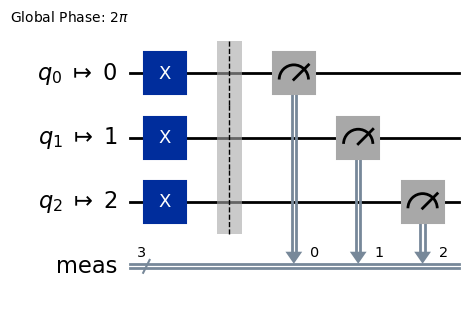

In [39]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
import numpy as np
from matplotlib import pyplot as plt


# Get a fake backend from the fake provider
backend = FakeManilaV2()
n_qubits = 3
# Create a simple circuit
circuit = QuantumCircuit(n_qubits)
theta = np.pi/2

# Apply RY gate to each qubit
for i in range(n_qubits):
    circuit.h(qubit=i)

    circuit.ry(theta, i)

circuit.measure_all()
circuit.draw('mpl', style="iqp")
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)
 
isa_circuit.draw("mpl", idle_wires=False)

In [40]:

observables_labels = ["IZZ", "ZIZ","ZZI","ZZZ"]
observables = [SparsePauliOp(label) for label in observables_labels]
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000
 
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")


>>> Job ID: czptfzznhqag008s865g


In [84]:
# Plot the result

 # This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()
values = pub_result.data.evs
 
errors = pub_result.data.stds
 
# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

AttributeError: 'function' object has no attribute 'evs'

In [55]:
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler
 
# Bell Circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
# Run the sampler job locally using AerSimulator.
# Session syntax is supported but ignored because local mode doesn't support sessions.
aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
isa_qc = pm.run(qc)
with Session(backend=aer_sim) as session:
    sampler = Sampler(mode=session)
    result = sampler.run([isa_qc],shots=100).result()

In [63]:
result.quasi_dists

AttributeError: 'PrimitiveResult' object has no attribute 'quasi_dists'

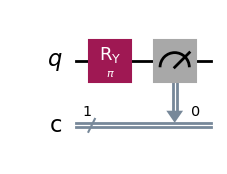

In [ ]:

# Create a 1-qubit circuit
qc = QuantumCircuit(1, 1)  # 1 qubit, 1 classical bit

# Start in |0⟩ (up) -- default state, so no need to initialize

# Rotate with RY(θ)
theta = np.pi   # example angle
qc.ry(theta, 0)

# Measure the qubit into the classical bit
qc.measure(0, 0)
qc.draw("mpl")

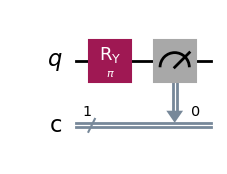

In [ ]:
aer_sim = AerSimulator()
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=3)
isa_qc = pm.run(qc)
isa_qc.draw("mpl")

In [79]:

from qiskit_aer import AerSimulator


with Session(backend=aer_sim) as session:
    sampler = Sampler(mode=session)
    job = sampler.run([isa_qc],shots=100)


result = job.result()

result

PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=100, num_bits=1>)), metadata={'shots': 100, 'circuit_metadata': {}})], metadata={'version': 2})

In [82]:

# Create circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)
qc.ry(np.pi, 0)      # Rotate
qc.measure(0, 0)     # Measure

# Use AerSimulator
aer_sim = AerSimulator()

# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=3)
isa_qc = pm.run(qc)

# Execute with simulator
job = aer_sim.run(isa_qc, shots=100)
result = job.result()

# Get bitstring counts
counts = result.get_counts()
print("Measurement counts:", counts)

Measurement counts: {'1': 100}


In [ ]:
classical_state_vector 